<center><span style="font-size:40px;"><b>NUTS vs HMC on GAUSSIAN POSTERIOR</b></span></center>

---

---

---

In [1]:
import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
import pandas as pd

# Set random seed for reproducibility
rng = np.random.default_rng(12345)

/home/benedetto/anaconda3/envs/inference/lib/python3.12/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


---

---

---

<center><span style="font-size:30px;"><b>1. SIMPLE CASE: UNCORRELATED N-DIM GAUSSIAN</b></span></center>

---

## 1.1 DATA GENERATION

We start from the simplest setting: a multivariate Gaussian with independent components (i.e. diagonal covariance matrix).

We generate data from:

$$
x_n \sim \mathcal{N}(\mu_{\text{true}}, \Sigma), \quad \Sigma = \text{diag}(\sigma_1^2, \dots, \sigma_D^2)
$$

Each dimension is independent and has its own mean $\mu_d$ and its own standard deviation $\sigma_d$.

### Sanity check (frequentist intuition)

For a Gaussian with known variance:

- The sample mean satisfies:
$$
\bar{x}_d \sim \mathcal{N}\left(\mu_d, \frac{\sigma_d^2}{N}\right)
$$

So:
- standard error = $\sigma_d / \sqrt{N}$
- we can compute a **z-score**:
\[
z_d = \frac{\bar{x}_d - \mu_d}{\sigma_d / \sqrt{N}}
\]

If everything is correct, these z-scores should look like samples from $\mathcal{N}(0,1)$.

This is a useful sanity check before running MCMC.

In [7]:
D = 10      # number of dimensions
N = 3000    # number of observations

# TRUE PARAMETERS (ground truth) ----------------------------
mu_true = np.linspace(-3.0, 3.0, D)      # different mean in each dimension
sigma_true = np.array([0.4, 0.7, 1.2, 0.9, 0.5, 1.5, 0.8, 1.1, 0.6, 1.3]) # different std in each dimension


# DATA GENERATION ----------------------------
# the array 'X' will contain all our 3000x10 samples
# Shape: (N, D) = (3000, 10). Each column d has N values taken from ~ N(mu_true[d], sigma_true[d]^2)
X = rng.normal(loc=mu_true, scale=sigma_true, size=(N, D))

# some statistics:
xbar = X.mean(axis=0)                   # Sample mean
se_xbar = sigma_true / np.sqrt(N)       # standard error of the sample mean
z_scores = (xbar - mu_true) / se_xbar   # Z-scores: should be ~ N(0,1)

# PRINT RESULTS ----------------------------
np.set_printoptions(precision=3, suppress=True)
print(f"True mu:\n{mu_true}")
print(f"\nSample mean:\n{xbar}")
print(f"\nStd error of sample mean:\n{se_xbar}")
print(f"\nZ-scores (should be ~ N(0,1)):\n{z_scores}")

True mu:
[-3.    -2.333 -1.667 -1.    -0.333  0.333  1.     1.667  2.333  3.   ]

Sample mean:
[-2.993 -2.333 -1.65  -1.022 -0.311  0.37   1.016  1.68   2.327  2.971]

Std error of sample mean:
[0.007 0.013 0.022 0.016 0.009 0.027 0.015 0.02  0.011 0.024]

Z-scores (should be ~ N(0,1)):
[ 0.948  0.025  0.77  -1.334  2.459  1.321  1.078  0.676 -0.538 -1.214]


---

## 1.2 SAMPLING

We now define a Bayesian model to infer the unknown mean vector $\mu$ starting from the samples we obtained. We assume:

$$
x_n \sim \mathcal{N}(\mu, \Sigma), \quad \Sigma = \text{diag}(\sigma_1^2, \dots, \sigma_D^2)
$$

The covariance is known and diagonal. The unknown parameter is the mean vector $\mu \in \mathbb{R}^D$.

#### PRIOR

We place an independent prior on each component of $\mu$:
$$
\mu_d \sim \mathcal{N}(0, 10^2)
$$

This is a **weak prior**, wide enough not to dominate the likelihood, centered at 0 for symmetry.

#### LIKELIHOOD

Given $\mu$, observations are independent:
$$
X_{n,d} \sim \mathcal{N}(\mu_d, \sigma_d^2)
$$

#### POSTERIOR

Given tha data $X$, the posterior is given by the Bayes theorem:
$$
p(\mu \mid X) \propto p(X \mid \mu)\, p(\mu)
$$

Because both prior and likelihood are Gaussian, the posterior is also Gaussian (analytically known).

#### SAMPLING ALGORITHM

We use NUTS (No-U-Turn Sampler) for now. We will later compare NUTS with standard HMC.

In [9]:
with pm.Model() as model:

    # PRIOR ---------------------------R
    mu = pm.Normal("mu", mu=0.0, sigma=10.0, shape=D)

    # LIKELIHOOD ---------------------------
    y = pm.Normal("y", mu=mu, sigma=sigma_true, observed=X) # automatic broadcasting (D,) → (N, D)

    # SAMPLING (NUTS) ----------------------------
    idata = pm.sample(
        draws=2000,           # number of posterior samples
        tune=2000,            # warm-up iterations (adaptation phase) (will be discarded)
        chains=4,             # number of runs
        cores=4,              # number of cpu cores used
        target_accept=0.9,    # higher = safer, fewer divergences
        random_seed=2026,
        nuts_sampler="pymc",  # explicit NUTS backend
        progressbar=True,
        return_inferencedata=True  # ensures to return an easy to manipulate InferenceData object for ArviZ
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 10 seconds.


We ran 4 chains with 2000 'true' samples each, for a total of 8000 samples.

---

## 1.3 DIAGNOSTICS

We use `az.summary` to compute a table of **posterior statistics** for the sampled variables.

Given the MCMC samples, it returns (for each parameter):
* **mean**:  Posterior mean of the parameter (estimate of $ \mathbb{E}[\mu \mid \text{data}] $)
* **sd**: Posterior standard deviation
* **hdi_3%**: Lower bound of the **94% Highest Density Interval (HDI)** (yeah, it's 94% by default for some reason). The HDI is the shortest interval that contains the specified probability mass.
* **hdi_97%**: Upper bound of the HDI. Interpretation: “There is ~94% posterior probability that the true parameter lies in this interval”
* **mcse_mean**: Monte Carlo Standard Error of the mean estimate. How much error comes from finite sampling (should be small)
* **mcse_sd**: Monte Carlo error of the standard deviation estimate. These last two should be **much smaller than sd**.
* **ess_bulk**: Effective number of *independent* samples for the **main bulk** of the posterior. Accounts for autocorrelation. Higher = better. This tells us “How well do I estimate the mean / central mass?”
* **ess_tail**: Effective samples for the **tails** (extreme values). Important for intervals and uncertainty. This tells us “How well do I estimate extremes / intervals?”. Typically ess_tail < ess_bulk. 

If chains are well mixed and roughly independent from each other, then combining them gives more information than a single long correlated chain. Even if you drew e.g. 8000 samples, this can give us ~15000–19000 *effective* samples (since 4 chains combined). So ESS > N is basically saying: “These samples behave better than a single correlated chain of length N”.

* **r_hat**: Measures agreement between chains. We run multiple chains (e.g. 4 in this case), and if they all explore the space well and mix properly, then they should look statistically identical. $\hat{R}$ measures: “Are chains consistent with each other, or still stuck in different regions?”. Ideal value: **≈ 1.00**
    * **≤ 1.01 → excellent**
    * **> 1.05 → warning**
    * **≫ 1 → bad (not converged)**
$$
\hat{R} = \frac{ \text{(variance across chains)} }   { \text{(variance within chains)} }
$$

In [11]:
summary = az.summary(idata, var_names=["mu"], round_to=4) # round_to simply controls the digits output
display(summary)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu[0],-2.9930,0.0072,-3.0064,-2.9795,0.0001,0.0001,15994.9457,5416.4035,1.0011
mu[1],-2.3332,0.0128,-2.3565,-2.3082,0.0001,0.0002,20633.4691,5431.4597,1.0017
mu[2],-1.6498,0.0215,-1.6901,-1.6090,0.0002,0.0003,16485.9751,5699.5123,1.0007
mu[3],-1.0218,0.0166,-1.0521,-0.9905,0.0001,0.0002,18087.3478,5395.8034,1.0001
mu[4],-0.3109,0.0091,-0.3271,-0.2929,0.0001,0.0001,14554.4515,5629.9096,1.0002
mu[5],0.3695,0.0270,0.3183,0.4202,0.0002,0.0004,17657.0151,5300.1839,1.0007
mu[6],1.0157,0.0143,0.9896,1.0435,0.0001,0.0002,16345.3789,5329.0182,1.0003
mu[7],1.6802,0.0199,1.6428,1.7182,0.0002,0.0003,16870.7760,5405.6690,1.0015
mu[8],2.3274,0.0109,2.3073,2.3480,0.0001,0.0001,18472.6028,5542.7041,1.0012
mu[9],2.9711,0.0236,2.9254,3.0144,0.0002,0.0003,15572.4134,6102.5111,0.9999


#### 1.3.5 Understanding the PyMC Data Structure

To navigate your model results, think of the data as a nested hierarchy—moving from a broad container down to specific numerical values.

* **`idata` (InferenceData):** This is the top-level *ArviZ InferenceData* object. Think of it as a multi-layered "database" for your Bayesian project. It stores everything from the actual samples to the original observed data and sampling metadata.
* **`idata.posterior` (xarray Dataset):** This is the most important "group" inside the container. It is an *xarray Dataset* specifically holding the samples drawn during the MCMC process. It is organized into dimensions; in our case, the shape is (4 chains × 2000 draws × 10 mu\_dim).
* **`idata.posterior["mu"]` (xarray DataArray):** This extracts only the samples associated with the parameter $\mu$. Unlike a raw NumPy array, this **DataArray** keeps its labels (coordinates and dimensions) attached, so you always know which number belongs to which chain and feature.
* **`.mean(dim=("chain", "draw"))`:** This command tells xarray exactly which dimensions to "collapse." By averaging over both `chain` and `draw`, you are aggregating all 8,000 samples ($4 \times 2000$) to find the single representative mean for each of your 10 features.
* **`.values`:** The "escape hatch" back to standard Python. Adding this at the end strips away the xarray labels and metadata, returning a clean **NumPy array** of size 10.

In [12]:
idata

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

In [15]:
# Posterior mean estimate for mu
# we take all sampled values of mu and take the mean
mu_post_mean = idata.posterior["mu"].mean(dim=("chain", "draw")).values
mu_post_sd = idata.posterior["mu"].std(dim=("chain", "draw")).values

print("\nPosterior mean(mu):", mu_post_mean)
print("Posterior sd(mu):  ", mu_post_sd)
print("True mu:           ", mu_true)


Posterior mean(mu): [-2.993 -2.333 -1.65  -1.022 -0.311  0.369  1.016  1.68   2.327  2.971]
Posterior sd(mu):   [0.007 0.013 0.022 0.017 0.009 0.027 0.014 0.02  0.011 0.024]
True mu:            [-3.    -2.333 -1.667 -1.    -0.333  0.333  1.     1.667  2.333  3.   ]


In [16]:
# Credible intervals + coverage check
hdi = az.hdi(idata, var_names=["mu"], hdi_prob=0.95)["mu"].values  # shape (D, 2)
covered = (mu_true >= hdi[:, 0]) & (mu_true <= hdi[:, 1])          # boolean mask

print("\n95% HDI for each dimension (low, high):")
for d in range(D):
    print(f"d={d:2d}  HDI=({hdi[d,0]: .4f}, {hdi[d,1]: .4f})  true={mu_true[d]: .4f}  covered={covered[d]}")

print("\nCoverage count:", covered.sum(), "/", D)


95% HDI for each dimension (low, high):
d= 0  HDI=(-3.0064, -2.9781)  true=-3.0000  covered=True
d= 1  HDI=(-2.3574, -2.3070)  true=-2.3333  covered=True
d= 2  HDI=(-1.6929, -1.6086)  true=-1.6667  covered=True
d= 3  HDI=(-1.0522, -0.9879)  true=-1.0000  covered=True
d= 4  HDI=(-0.3284, -0.2929)  true=-0.3333  covered=False
d= 5  HDI=( 0.3155,  0.4220)  true= 0.3333  covered=True
d= 6  HDI=( 0.9876,  1.0438)  true= 1.0000  covered=True
d= 7  HDI=( 1.6407,  1.7196)  true= 1.6667  covered=True
d= 8  HDI=( 2.3063,  2.3487)  true= 2.3333  covered=True
d= 9  HDI=( 2.9248,  3.0170)  true= 3.0000  covered=True

Coverage count: 9 / 10


Let's compute the exact Bayesian posterior (in closed form), and then compare it to the NUTS posterior estimate from PyMC.

In [17]:
# Compare to analytic posterior for Normal likelihood with Normal prior:
# prior: mu_d ~ Normal(0, 10^2)
# likelihood: x_i,d ~ Normal(mu_d, sigma_true[d]^2)
# posterior: mu_d | X ~ Normal(m_post, v_post)
prior_var = 10.0**2
like_var = sigma_true**2
post_var_analytic = 1.0 / (1.0/prior_var + N/like_var)
post_mean_analytic = post_var_analytic * (0.0/prior_var + N*xbar/like_var)

print("\nAnalytic posterior mean:", post_mean_analytic)
print("Analytic posterior sd:  ", np.sqrt(post_var_analytic))

print("\nAbs error (NUTS mean - analytic mean):", np.abs(mu_post_mean - post_mean_analytic))
print("Max abs error:", np.max(np.abs(mu_post_mean - post_mean_analytic)))


Analytic posterior mean: [-2.993 -2.333 -1.65  -1.022 -0.311  0.37   1.016  1.68   2.327  2.971]
Analytic posterior sd:   [0.007 0.013 0.022 0.016 0.009 0.027 0.015 0.02  0.011 0.024]

Abs error (NUTS mean - analytic mean): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Max abs error: 0.0001901118220049014


---

## 1.4 VISUALIZATION

`az.plot_trace()` is like the *MCMC Heart Rate Monitor*. It checks if your sampler actually worked. For every parameter, it generates two side-by-side plots:
* **Left Side (Density Plot):** This shows the distribution of your samples. 
* **Right Side (Rank/Trace Plot):** This shows the sequence of samples across the "draws.
    * **Good:** All chains are overlapping and zig-zagging rapidly around a central value.
    * **Bad:** One chain is drifting upward, or they look like "snakes" (this indicates high autocorrelation and poor mixing).

With `compat=True` we can see all 10 dimensions of μ onto the same plot using different colors, which is great for a "quick glance" to see if any of the 10 parameters are acting up compared to the others.

array([[<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>]],
      dtype=object)

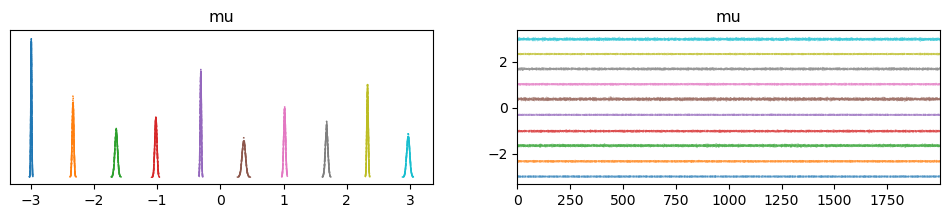

In [27]:
az.plot_trace(idata, var_names=["mu"], compact=True)   # quick view

array([[<Axes: title={'center': 'mu\n0'}>,
        <Axes: title={'center': 'mu\n0'}>],
       [<Axes: title={'center': 'mu\n1'}>,
        <Axes: title={'center': 'mu\n1'}>],
       [<Axes: title={'center': 'mu\n2'}>,
        <Axes: title={'center': 'mu\n2'}>],
       [<Axes: title={'center': 'mu\n3'}>,
        <Axes: title={'center': 'mu\n3'}>],
       [<Axes: title={'center': 'mu\n4'}>,
        <Axes: title={'center': 'mu\n4'}>],
       [<Axes: title={'center': 'mu\n5'}>,
        <Axes: title={'center': 'mu\n5'}>],
       [<Axes: title={'center': 'mu\n6'}>,
        <Axes: title={'center': 'mu\n6'}>],
       [<Axes: title={'center': 'mu\n7'}>,
        <Axes: title={'center': 'mu\n7'}>],
       [<Axes: title={'center': 'mu\n8'}>,
        <Axes: title={'center': 'mu\n8'}>],
       [<Axes: title={'center': 'mu\n9'}>,
        <Axes: title={'center': 'mu\n9'}>]], dtype=object)

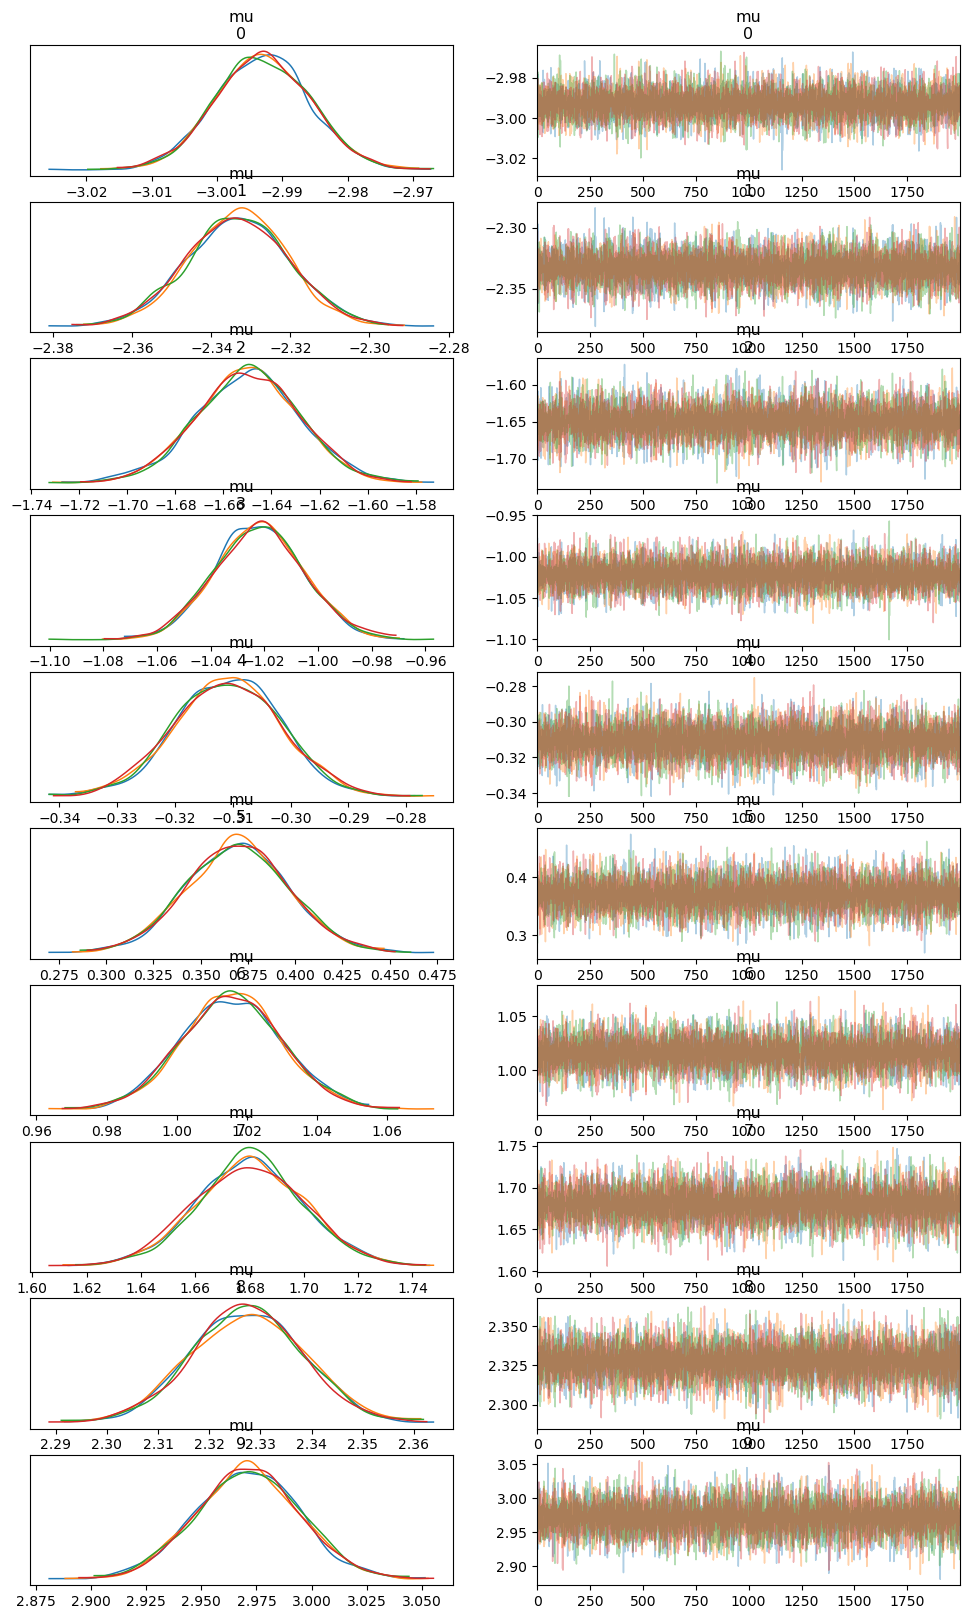

In [25]:
az.plot_trace(idata, var_names=["mu"], compact=False)

While the trace plot looks at parameters one by one, `az.plot_pair()` looks at **how they interact**. It creates a scatter plot (or "pair plot") of one parameter against another. It is useful for:
* **Identifying Correlations:** If you plot $\mu_1$ vs $\mu_2$ and see a tight diagonal line, it means those two variables are highly correlated. The model can’t easily tell them apart.
* **Visualizing the "Posterior Surface":** It helps you see the "shape" of the high-probability region.
* **Divergences:** If your sampler struggled (e.g., hit a "divergence"), `plot_pair` can highlight those specific points in red. This helps you find the "problem neighborhoods" in your geometry where the math broke down.

/home/benedetto/anaconda3/envs/inference/lib/python3.12/site-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


array([[<Axes: ylabel='mu\n0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='mu\n1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='mu\n2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='mu\n3'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='mu\n4'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='mu\n5'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='mu\n6'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='mu\n0', ylabel='mu\n7'>, <Axes: xlabel='mu\n1'>,
        <Axes: xlabel='mu\n2'>, <Axes: xlabel='mu\n3'>,
        <Axes: xlabel='mu\n4'>, <Axes: xlabel='mu\n5'>,
        <Axes: xlabel='mu\n6'>, <Axes: 

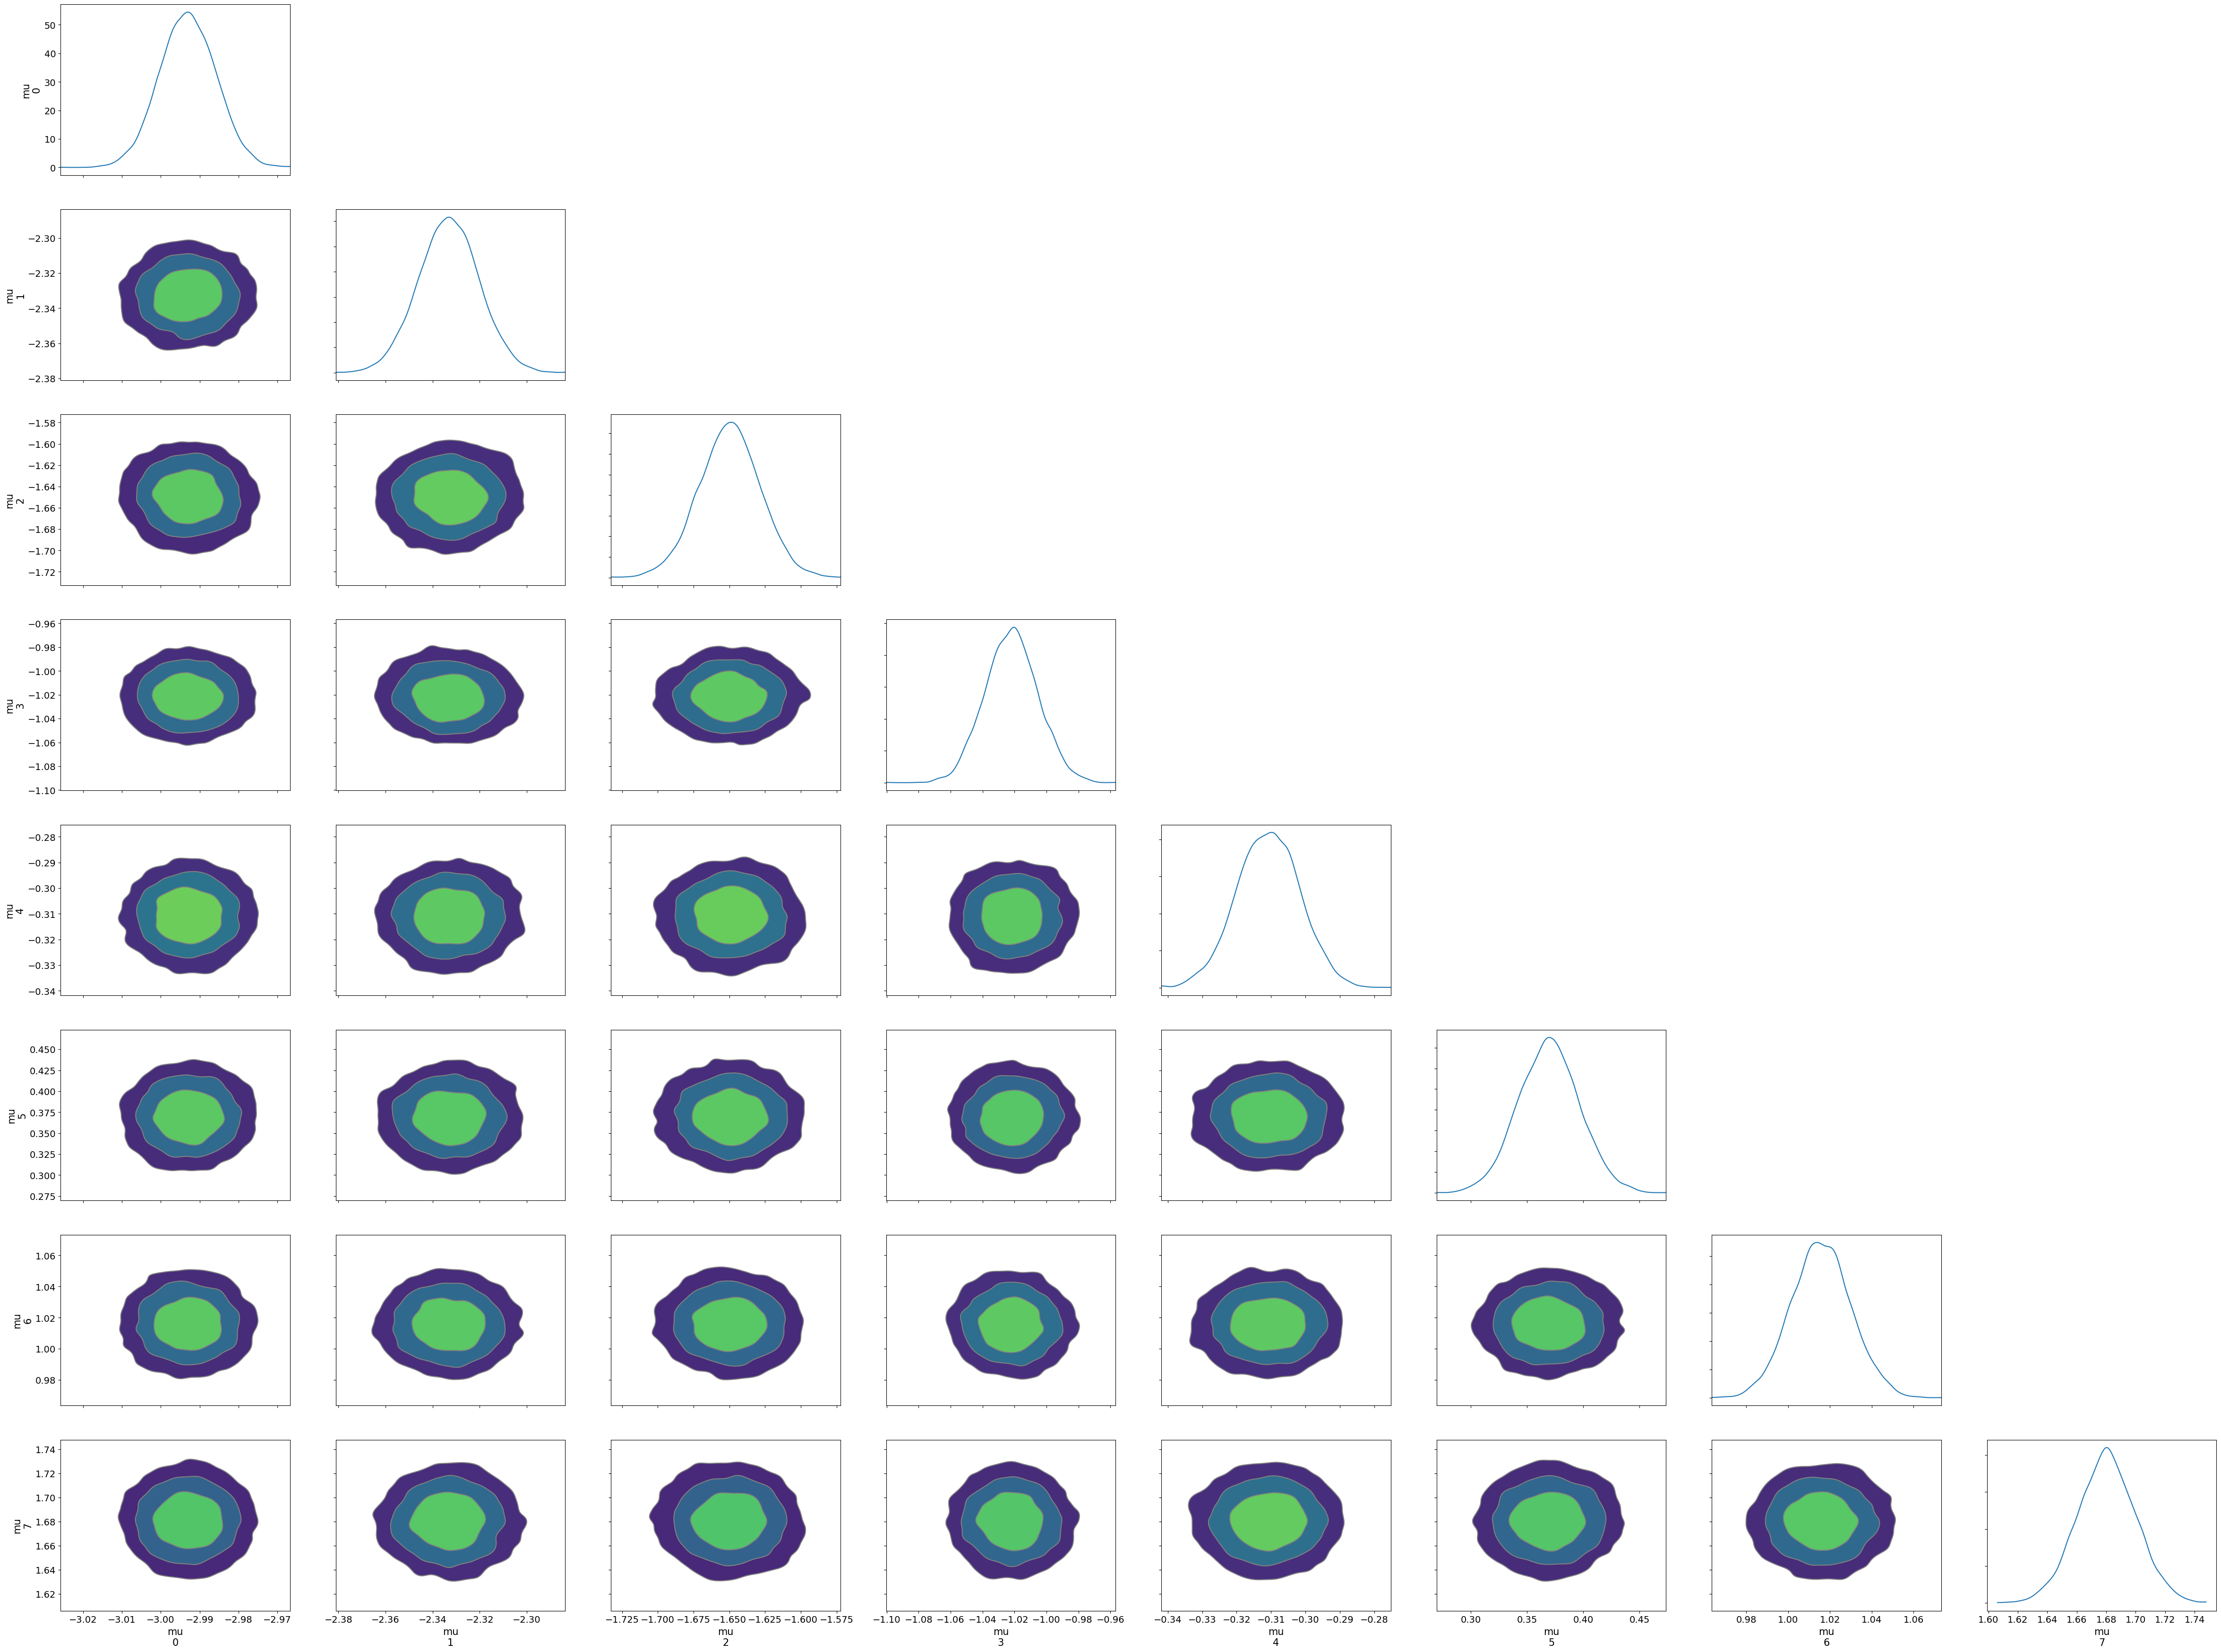

In [28]:
az.plot_pair(idata, var_names=["mu"], kind="kde", marginals=True)

As expected for the uncorrelated gaussian case, we see circular blobs, which means our variables are **uncorrelated**.

---

---

---

<center><span style="font-size:30px;"><b>2. GENERAL CASE: CORRELATED N-DIM GAUSSIAN</b></span></center>

---

## 2.1 DATA GENERATION

We now move to a more challenging setting: a **multivariate Gaussian with full covariance matrix**, i.e. correlated dimensions. This is where standard HMC becomes sensitive to tuning and NUTS shows its advantage (automatic adaptation).

We generate data from:
$$
x_n \sim \mathcal{N}(\mu_{\text{true}}, \Sigma_{\text{true}})
$$

where $\mu_{\text{true}} \in \mathbb{R}^D$ is the mean vector, $\Sigma_{\text{true}} \in \mathbb{R}^{D \times D}$ is a full covariance matrix, and off-diagonal terms introduce **correlations between dimensions**.

We build it in three steps:

1. Define per-dimension scales:
$$
S = \text{diag}(\sigma_1, \dots, \sigma_D)
$$

2. Generate a random correlation matrix $R$:
    - start from a random matrix $A$
    - compute $A A^T$ (in this way we obtain a symmetric and positive definite matrix, like a correlation matrix should be)
    - normalize to obtain correlations (normalization shrinks the values so the diagonal is exactly 1, a variable’s correlation with itself)

3. Control correlation strength (from identity matrix to very much correlated):
$$
R \leftarrow \alpha R + (1 - \alpha) I
$$
    - $\alpha \in [0,1]$
    - $\alpha \to 1$ → stronger correlations
    - $\alpha \to 0$ → nearly independent variables (identity matrix)

Finally we obtain our correlation matrix:
$$
\Sigma_{\text{true}} = S R S
$$

Computationally, when you multiply $S$ (which is a diagonal matrix) on the left of $R$, you are performing a *row-wise scaling*. Every element in *Row 1* of the correlation matrix $R$ is multiplied by $\sigma_1$. Every element in *Row 2* is multiplied by $\sigma_2$. Effect: You have scaled the "vertical" magnitude of the relationships.

Now, you take that result and multiply by $S$ on the right. This performs a *column-wise scaling*. Every element in *Column 1* is multiplied by $\sigma_1$. Every element in *Column 2* is multiplied by $\sigma_2$. Effect: You have now scaled the "horizontal" magnitude.

We do this because a covariance matrix entry $\Sigma_{ij}$ represents the relationship between variable $i$ and variable $j$. To turn a correlation ($r_{ij}$) into a covariance, you must multiply it by *both* standard deviations:
$$\text{Covariance}(i, j) = \sigma_i \cdot r_{ij} \cdot \sigma_j$$


#### SAMPLING WITH CHOLESKY DECOMPOISTION

The **Cholesky Decomposition**, is a way of "taking the square root" of a matrix. In linear algebra, if you have a symmetric, positive-definite matrix $\Sigma$ (like a Covariance matrix), the Cholesky decomposition finds a *Lower Triangular Matrix* $L$ such that:

$$\Sigma = L L^T$$

To generate correlated Gaussian samples we can use:

$$
X = \mu + Z L^T, \quad Z \sim \mathcal{N}(0, I)
$$

This transforms uncorrelated noise into samples with covariance $\Sigma$.

We use it cause it's efficient and stable.


In [4]:
D = 10     # number of dimensions
N = 4000   # number of observations

# TRUE PARAMETERS (ground truth) ----------------------------
mu_true = np.linspace(-3.0, 3.0, D)

# BUILD COVARIANCE MATRIX -------------------------------------
sigmas = np.array([0.4, 0.7, 1.2, 0.9, 0.5, 1.5, 0.8, 1.1, 0.6, 1.3])
S = np.diag(sigmas)  # scale matrix
# Random SPD matrix → convert to correlation matrix
A = rng.normal(size=(D, D))
R_unnorm = A @ A.T                         # symmetric positive definite
d = np.sqrt(np.diag(R_unnorm))
R = R_unnorm / np.outer(d, d)              # normalize → correlation matrix
# Blend with identity to control correlation strength / conditioning
alpha = 0.75                               # higher = stronger correlations
R = alpha * R + (1 - alpha) * np.eye(D)
# Final covariance matrix
Sigma_true = S @ R @ S


# GENERATE DATA --------------------------------
# Cholesky factor (Σ = L L^T)
L_true = np.linalg.cholesky(Sigma_true)
Z = rng.normal(size=(N, D))                # standard normal
X = mu_true + Z @ L_true.T                 # correlated samples

# some statistics
xbar = X.mean(axis=0)   # empirical mean
# empirical covariance (rowvar=False tells NumPy that the columns are the variables and the rows are the observations)
emp_cov = np.cov(X, rowvar=False)   


# PRINT RESULTS ----------------------------
np.set_printoptions(precision=3, suppress=True)
print("mu_true:", mu_true)
print("xbar:   ", xbar)

print("\nMean absolute error on mean:", np.mean(np.abs(xbar - mu_true)))
print("Covariance error:", np.linalg.norm(emp_cov - Sigma_true))

mu_true: [-3.    -2.333 -1.667 -1.    -0.333  0.333  1.     1.667  2.333  3.   ]
xbar:    [-2.996 -2.312 -1.668 -1.009 -0.317  0.379  1.005  1.64   2.331  2.998]

Mean absolute error on mean: 0.013244894187837458
Covariance error: 0.139553923045922


### 2.1.1 ANALYTIC POSTERIOR

Since both the prior and likelihood are Gaussian, the posterior can be computed in closed form.

- Prior:
$$
\mu \sim \mathcal{N}(0, \tau^2 I)
$$

- Likelihood:
$$
x_n \sim \mathcal{N}(\mu, \Sigma)
$$

- The posterior is Gaussian:
$$
\mu \mid X \sim \mathcal{N}(\mu_{\text{post}}, \Sigma_{\text{post}})
$$

with:

$$
\Sigma_{\text{post}}^{-1} = \frac{1}{\tau^2} I + N \Sigma^{-1}
$$

$$
\mu_{\text{post}} = \Sigma_{\text{post}} \left( N \Sigma^{-1} \bar{x} \right)
$$

This gives the exact posterior. We can compare MCMC (HMC / NUTS) against it.

In [7]:
# Prior: mu ~ N(0, tau^2 I)
tau = 10.0
prior_prec = (1.0 / tau**2) * np.eye(D)     # prior precision matrix

# Likelihood precision
Sigma_inv = np.linalg.inv(Sigma_true)       # Σ^{-1}
like_prec = N * Sigma_inv                   # N Σ^{-1}

# Posterior precision and covariance
post_prec = prior_prec + like_prec          # Σ_post^{-1}
post_cov = np.linalg.inv(post_prec)         # Σ_post

# Posterior mean
post_mean = post_cov @ (like_prec @ xbar)   # Σ_post (N Σ^{-1} x̄)

# PRINT RESULTS ----------------------------
print("\nAnalytic posterior mean:")
print(post_mean)

print("\nAnalytic posterior std (per dimension):")
print(np.sqrt(np.diag(post_cov)))

print("\nMean absolute error vs true mu:")
print(np.mean(np.abs(post_mean - mu_true)))


Analytic posterior mean:
[-2.996 -2.312 -1.668 -1.009 -0.317  0.379  1.005  1.64   2.331  2.998]

Analytic posterior std (per dimension):
[0.006 0.011 0.019 0.014 0.008 0.024 0.013 0.017 0.009 0.021]

Mean absolute error vs true mu:
0.013246549607681568


---

---

---

## 2.2 SAMPLING WITH NUTS

We now define the Bayesian model in PyMC. 

We use `pm.MvNormal` with the Cholesky factor (see above) instead of passing $\Sigma$ directly, because it is more numerically stable.

In [8]:
coords = {"dim": np.arange(D)}  # label dimensions for nicer outputs

with pm.Model(coords=coords) as model:

    # PRIOR: mu ~ N(0, tau^2 I)
    mu = pm.Normal("mu", mu=0.0, sigma=tau, dims="dim")

    # LIKELIHOOD: x_n ~ MVN(mu, Σ) using Cholesky factor
    y = pm.MvNormal("y", mu=mu, chol=L_true, observed=X)

    # NUTS sampling
    idata_nuts = pm.sample(
        draws=2000,            # posterior samples
        tune=2000,             # warm-up steps (will be discarded)
        chains=4,
        cores=4,
        target_accept=0.9,     # safer for correlated geometry
        random_seed=2026,
        progressbar=True,
        nuts_sampler="pymc",   # explicit NUTS backend
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 34 seconds.


### 2.2.1 COMPARE WITH ANALYTIC POSTERIOR

We now compare the MCMC results (NUTS) with the exact analytic posterior.

In [19]:
# Extract posterior samples for mu
mu_samples = idata_nuts.posterior["mu"]

# Posterior mean and std from NUTS
mu_post_mean = mu_samples.mean(dim=("chain", "draw")).values
mu_post_sd   = mu_samples.std(dim=("chain", "draw")).values

print("\nPosterior mean (NUTS):")
print(mu_post_mean)
print("\nPosterior std (NUTS):")
print(mu_post_sd)

# ----------------------------
# Error vs analytic posterior
# ----------------------------

abs_err = np.abs(mu_post_mean - post_mean)
print("\nAbs error vs analytic mean:")
print(abs_err)
print("\nMax abs error:", abs_err.max())

# ----------------------------
# 95% HDI coverage of true mu
# ----------------------------

hdi = az.hdi(idata_nuts, var_names=["mu"], hdi_prob=0.95)["mu"].values  # shape (D, 2)
covered = (mu_true >= hdi[:, 0]) & (mu_true <= hdi[:, 1])

print("\n95% HDI coverage of true mu:")
for d in range(D):
    print(f"d={d:2d}  HDI=({hdi[d,0]: .4f}, {hdi[d,1]: .4f})  true={mu_true[d]: .4f}  covered={covered[d]}")

print("\nCoverage count:", covered.sum(), "/", D)

# ----------------------------
# Diagnostics
summary = az.summary(idata_nuts, var_names=["mu"], round_to=4) # round_to simply controls the digits output
display(summary)


Posterior mean (NUTS):
[-2.996  -2.3122 -1.6678 -1.009  -0.3172  0.3789  1.0045  1.6404  2.3308
  2.9983]

Posterior std (NUTS):
[0.0063 0.0109 0.0188 0.0142 0.0079 0.0231 0.0124 0.0173 0.0096 0.0207]

Abs error vs analytic mean:
[0.     0.     0.0001 0.0002 0.0001 0.0003 0.     0.0002 0.     0.0001]

Max abs error: 0.0003388909671253604

95% HDI coverage of true mu:
d= 0  HDI=(-3.0086, -2.9840)  true=-3.0000  covered=True
d= 1  HDI=(-2.3332, -2.2906)  true=-2.3333  covered=False
d= 2  HDI=(-1.7032, -1.6301)  true=-1.6667  covered=True
d= 3  HDI=(-1.0362, -0.9813)  true=-1.0000  covered=True
d= 4  HDI=(-0.3330, -0.3022)  true=-0.3333  covered=False
d= 5  HDI=( 0.3326,  0.4225)  true= 0.3333  covered=True
d= 6  HDI=( 0.9807,  1.0292)  true= 1.0000  covered=True
d= 7  HDI=( 1.6070,  1.6749)  true= 1.6667  covered=True
d= 8  HDI=( 2.3128,  2.3503)  true= 2.3333  covered=True
d= 9  HDI=( 2.9593,  3.0407)  true= 3.0000  covered=True

Coverage count: 8 / 10


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu[0],-2.9960,0.0063,-3.0081,-2.9844,0.0001,0.0001,6898.6070,6132.1784,1.0006
mu[1],-2.3122,0.0109,-2.3331,-2.2922,0.0001,0.0001,7896.4673,6077.2324,1.0004
mu[2],-1.6678,0.0188,-1.7031,-1.6328,0.0002,0.0002,7351.6920,6456.2788,0.9999
mu[3],-1.0090,0.0142,-1.0352,-0.9829,0.0002,0.0001,6391.0685,5828.3876,1.0003
mu[4],-0.3172,0.0079,-0.3319,-0.3024,0.0001,0.0001,7088.4354,6119.9082,1.0002
mu[5],0.3789,0.0231,0.3347,0.4213,0.0003,0.0002,7383.0360,6013.2350,1.0001
mu[6],1.0045,0.0124,0.9808,1.0273,0.0002,0.0001,6634.7449,6033.8764,1.0002
mu[7],1.6404,0.0173,1.6067,1.6718,0.0002,0.0002,7481.9564,6136.2180,1.0006
mu[8],2.3308,0.0096,2.3132,2.3493,0.0001,0.0001,7602.9485,6299.1749,1.0008
mu[9],2.9983,0.0207,2.9627,3.0405,0.0002,0.0002,7887.8602,5701.8954,1.0001


---

## 2.2.2 VISUALIZATION

array([[<Axes: title={'center': 'mu'}>, <Axes: title={'center': 'mu'}>]],
      dtype=object)

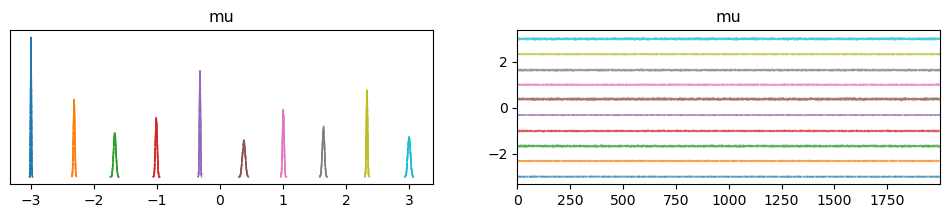

In [21]:
# quick view
az.plot_trace(idata_nuts, var_names=["mu"], compact=True)   # quick view

array([[<Axes: title={'center': 'mu\n0'}>,
        <Axes: title={'center': 'mu\n0'}>],
       [<Axes: title={'center': 'mu\n1'}>,
        <Axes: title={'center': 'mu\n1'}>],
       [<Axes: title={'center': 'mu\n2'}>,
        <Axes: title={'center': 'mu\n2'}>],
       [<Axes: title={'center': 'mu\n3'}>,
        <Axes: title={'center': 'mu\n3'}>],
       [<Axes: title={'center': 'mu\n4'}>,
        <Axes: title={'center': 'mu\n4'}>],
       [<Axes: title={'center': 'mu\n5'}>,
        <Axes: title={'center': 'mu\n5'}>],
       [<Axes: title={'center': 'mu\n6'}>,
        <Axes: title={'center': 'mu\n6'}>],
       [<Axes: title={'center': 'mu\n7'}>,
        <Axes: title={'center': 'mu\n7'}>],
       [<Axes: title={'center': 'mu\n8'}>,
        <Axes: title={'center': 'mu\n8'}>],
       [<Axes: title={'center': 'mu\n9'}>,
        <Axes: title={'center': 'mu\n9'}>]], dtype=object)

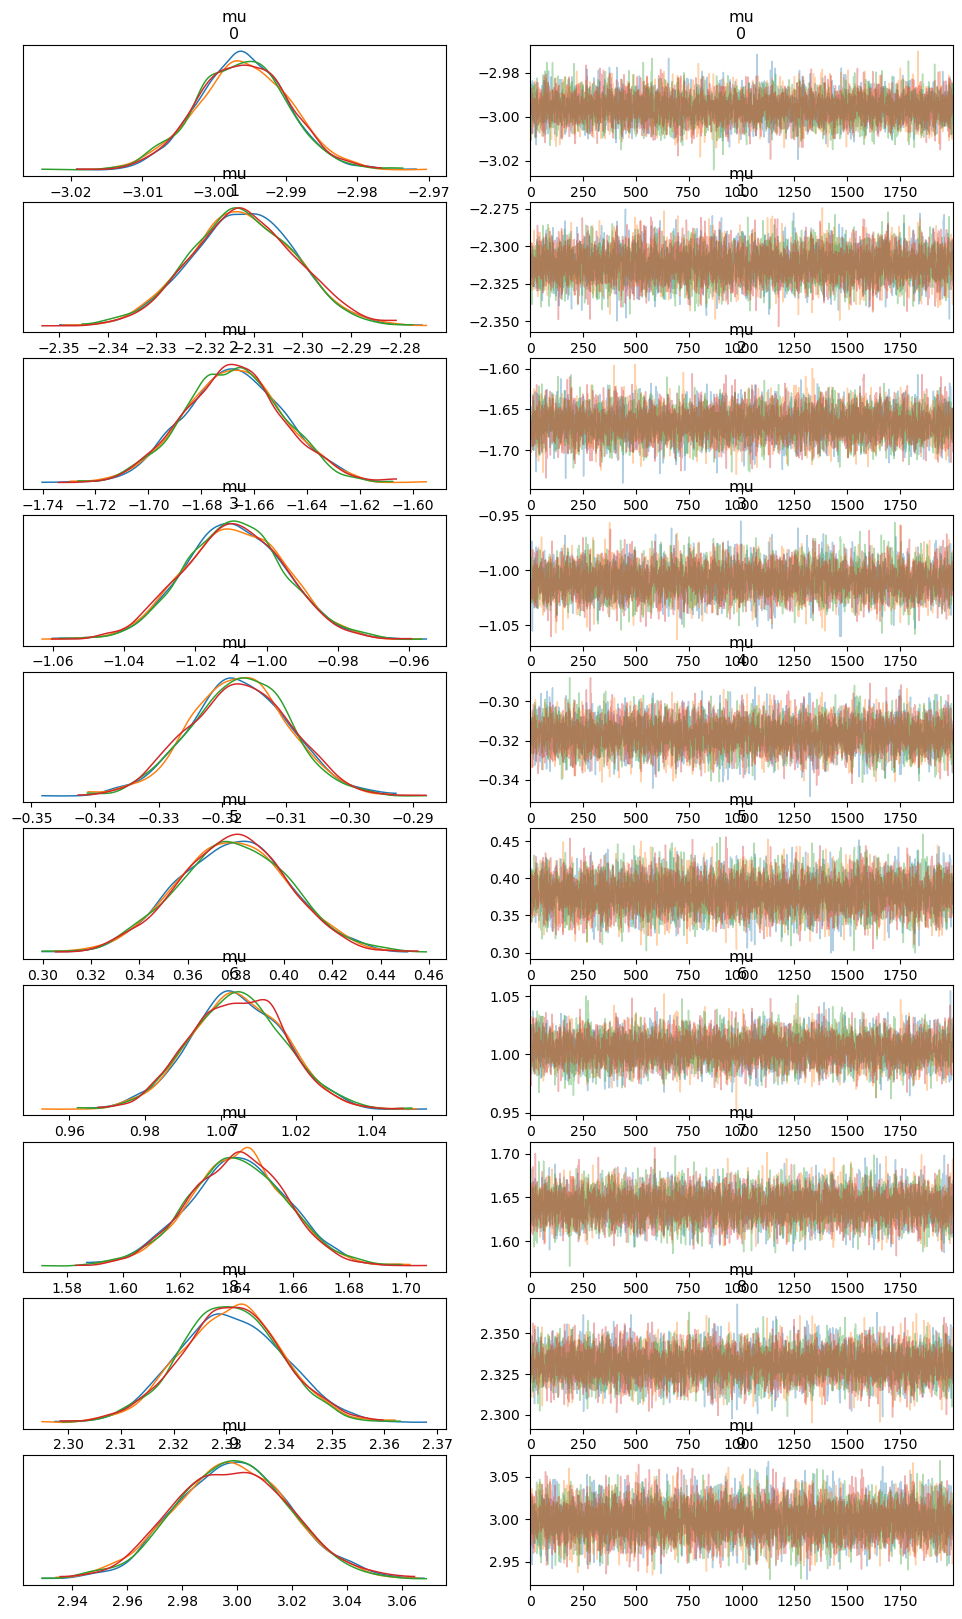

In [22]:
az.plot_trace(idata_nuts, var_names=["mu"], compact=False)

/home/benedetto/anaconda3/envs/inference/lib/python3.12/site-packages/arviz/plots/backends/matplotlib/pairplot.py:223: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


array([[<Axes: ylabel='mu\n0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='mu\n1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='mu\n2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='mu\n3'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='mu\n4'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='mu\n5'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='mu\n6'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='mu\n0', ylabel='mu\n7'>, <Axes: xlabel='mu\n1'>,
        <Axes: xlabel='mu\n2'>, <Axes: xlabel='mu\n3'>,
        <Axes: xlabel='mu\n4'>, <Axes: xlabel='mu\n5'>,
        <Axes: xlabel='mu\n6'>, <Axes: 

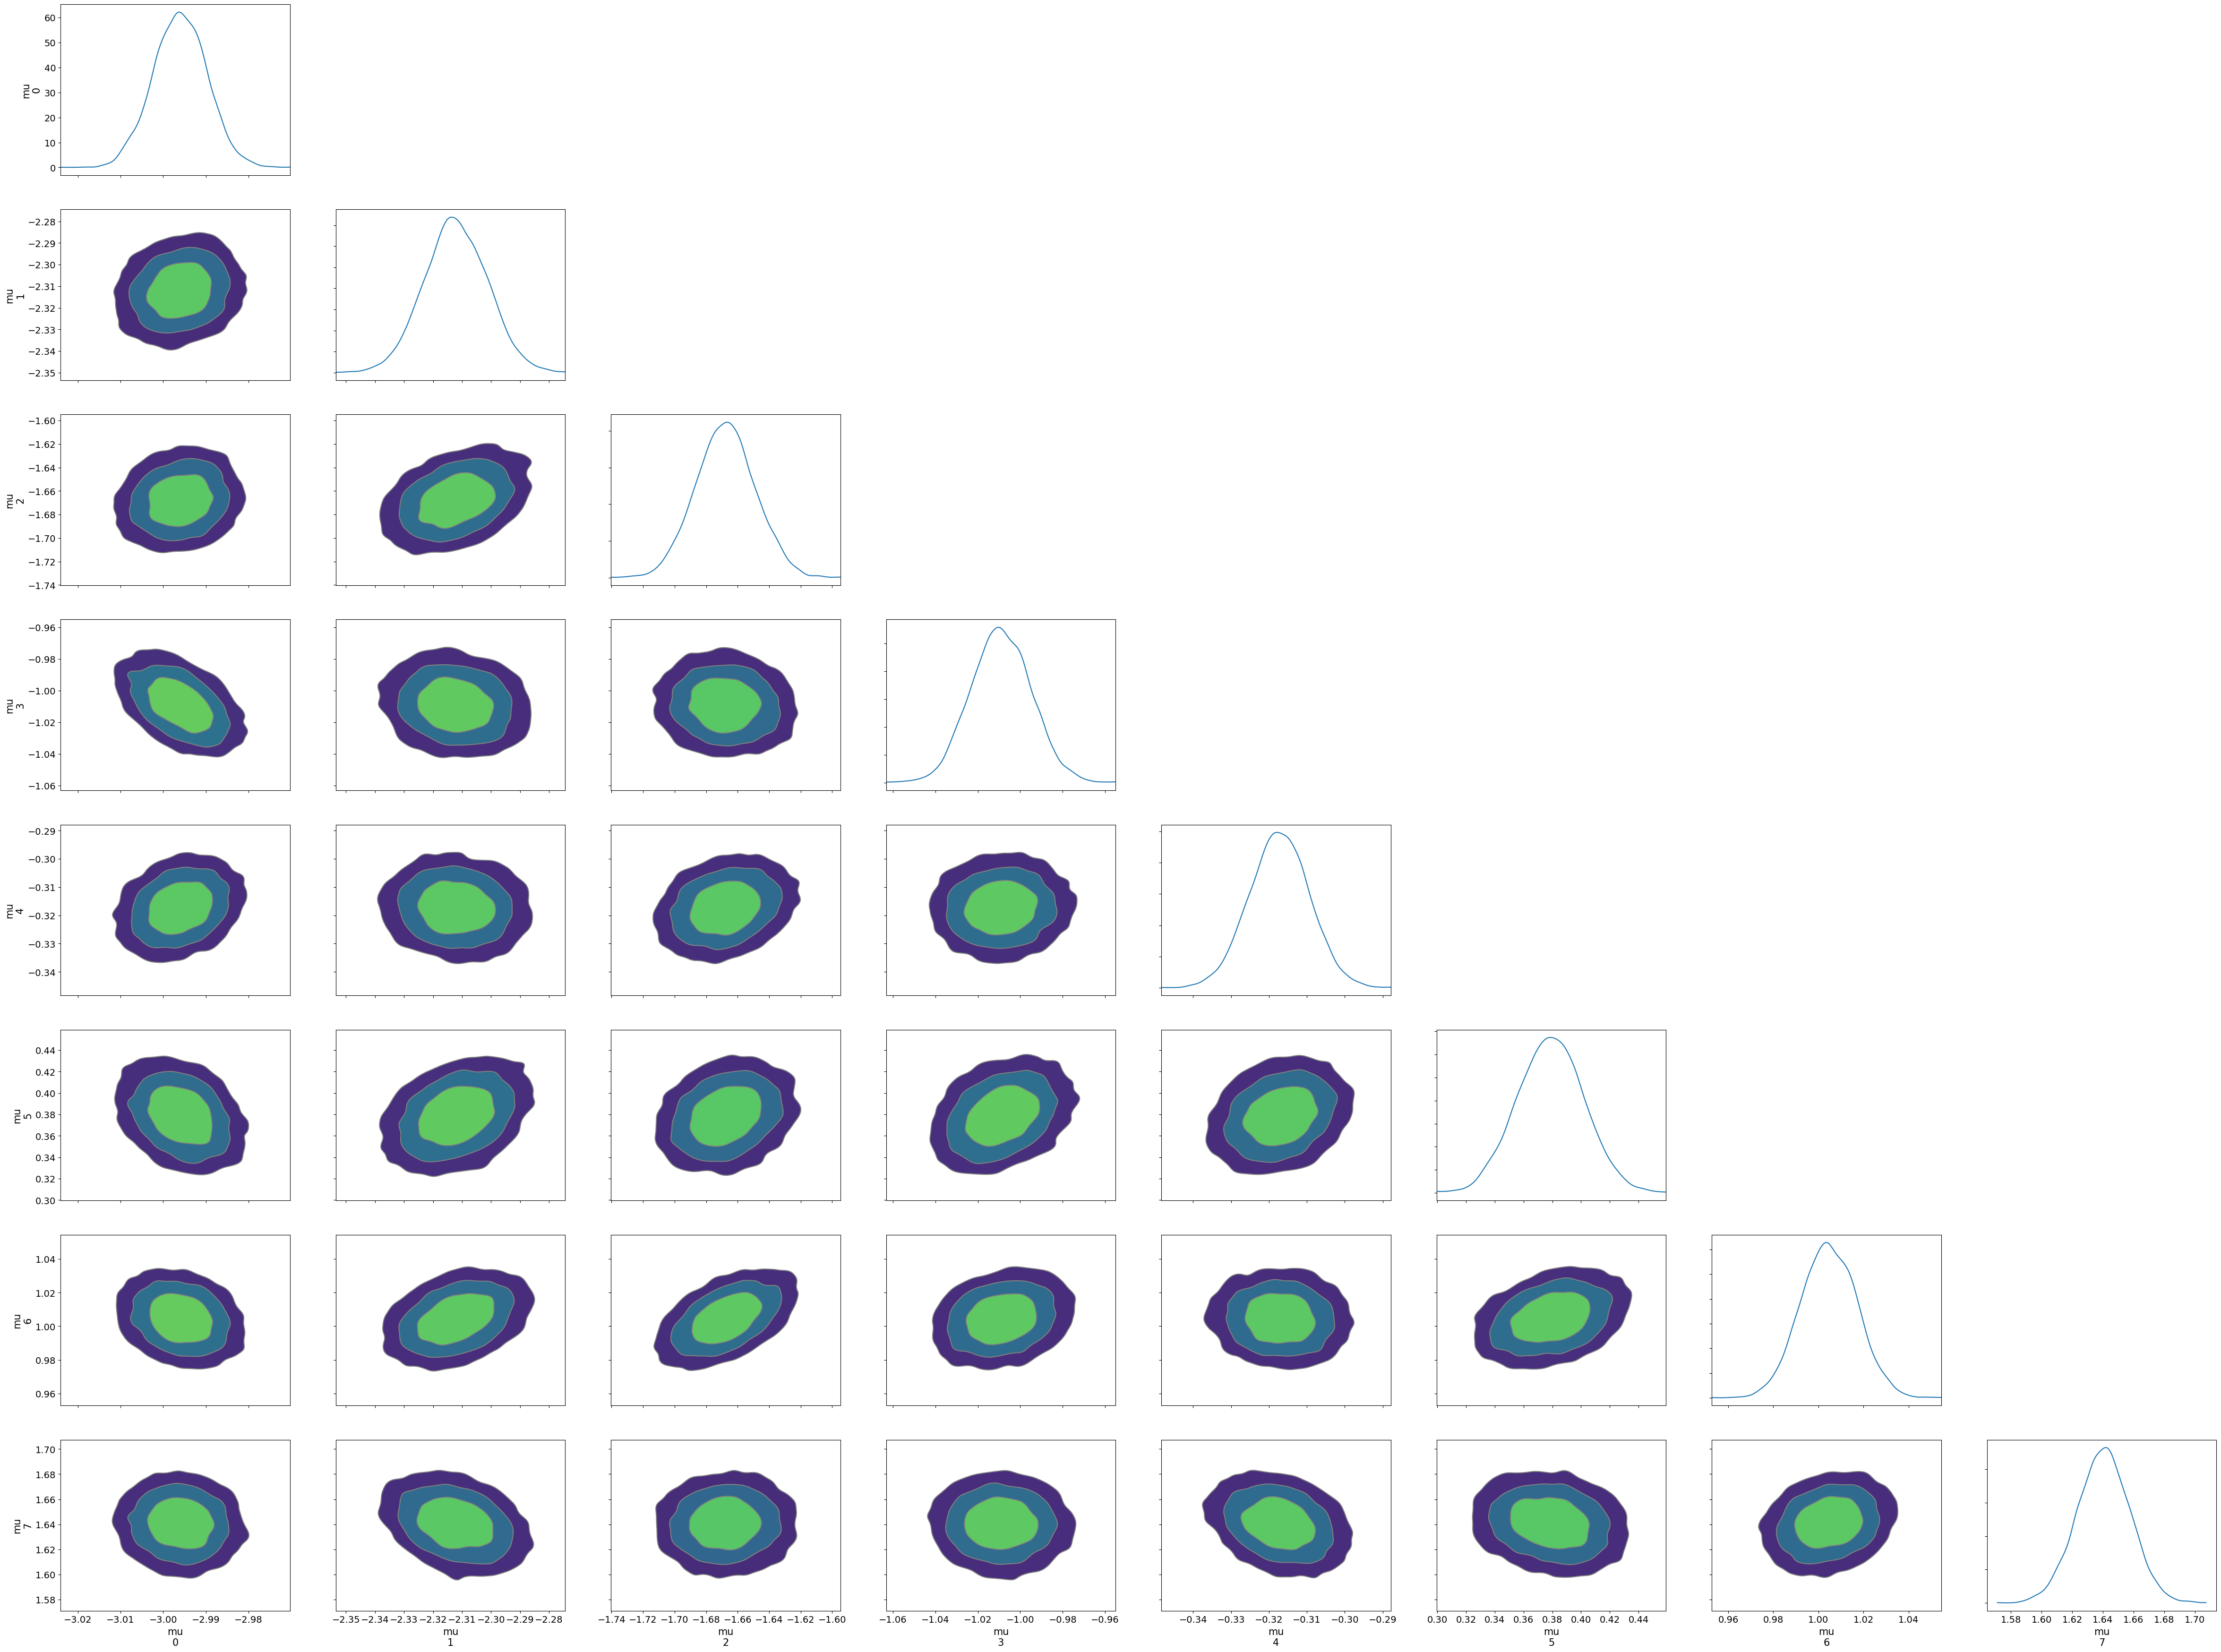

In [23]:
az.plot_pair(idata_nuts, var_names=["mu"], kind="kde", marginals=True)

As expected, we see some correlation this time.

---

---

---

## 2.3 SAMPLING WITH HMC (TO BE CHECKED)

We now run standard Hamiltonian Monte Carlo (HMC) on the same model of multivariate gaussians.

Differently from before, HMC requires **manual tuning** of two parameters:
- **Step size ($\epsilon$)**  → size of each leapfrog step
- **Number of steps ($L$)**   → trajectory length ($\approx L \cdot \epsilon$)

So the proposal is built by simulating Hamiltonian dynamics for $L$ steps.
- If $\epsilon$ is too large → unstable trajectories, low acceptance  
- If $\epsilon$ is too small → slow exploration  
- If $L$ is too small → random walk behavior  
- If $L$ is too large → wasted computation or U-turns  

Compare HMC vs NUTS:
- accuracy (posterior mean)
- efficiency (ESS)
- robustness (tuning sensitivity)

In [26]:
with pm.Model(coords=coords) as model_hmc:

    # PRIOR: mu ~ N(0, tau^2 I) (same as before)
    mu = pm.Normal("mu", mu=0.0, sigma=tau, dims="dim")

    # LIKELIHOOD: x_n ~ MVN(mu, Σ) via Cholesky (same as before)
    y = pm.MvNormal("y", mu=mu, chol=L_true, observed=X)

    # ----------------------------
    # HMC kernel (manual tuning)
    # ----------------------------
    step = pm.HamiltonianMC(
        step_scale=0.2,      # initial step size ε (adapted during tuning)
        path_length=2.0,     # total trajectory length (≈ ε * L)
        target_accept=0.8
    )

    
    # SAMPLING ----------------------------
    idata_hmc = pm.sample(
        draws=2000,            # posterior samples
        tune=2000,             # warm-up (step size adaptation happens here)
        step=step,             # use HMC instead of NUTS
        chains=4,
        cores=4,
        random_seed=2026,
        progressbar=True,
        return_inferencedata=True
    )

Multiprocess sampling (4 chains in 4 jobs)
HamiltonianMC: [mu]


Output()

/home/benedetto/anaconda3/envs/inference/lib/python3.12/site-packages/pymc/step_methods/hmc/hmc.py:171: RuntimeWarning: overflow encountered in exp
  accept_stat = min(1, np.exp(-energy_change))
/home/benedetto/anaconda3/envs/inference/lib/python3.12/site-packages/pymc/step_methods/hmc/hmc.py:171: RuntimeWarning: overflow encountered in exp
  accept_stat = min(1, np.exp(-energy_change))
/home/benedetto/anaconda3/envs/inference/lib/python3.12/site-packages/pymc/step_methods/hmc/hmc.py:171: RuntimeWarning: overflow encountered in exp
  accept_stat = min(1, np.exp(-energy_change))
/home/benedetto/anaconda3/envs/inference/lib/python3.12/site-packages/pymc/step_methods/hmc/hmc.py:171: RuntimeWarning: overflow encountered in exp
  accept_stat = min(1, np.exp(-energy_change))
/home/benedetto/anaconda3/envs/inference/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:316: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
/home/benedetto/anaconda3/envs

ValueError: Not enough samples to build a trace.

In [ ]:
print(model_hmc.debug())

In [27]:
print(idata_hmc)

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data


---

### 2.3.1 COMPARE WITH ANALYTICS POSTERIOR

In [ ]:
# Extract posterior samples for mu
mu_samples_hmc = idata_hmc.posterior["mu"]

# Posterior mean and std from NUTS
mu_post_mean_hmc = mu_samples_hmc.mean(dim=("chain", "draw")).values
mu_post_sd_hmc   = mu_samples_hmc.std(dim=("chain", "draw")).values

print("\nPosterior mean (NUTS):")
print(mu_post_mean_hmc)
print("\nPosterior std (NUTS):")
print(mu_post_sd_hmc)

# ----------------------------
# Error vs analytic posterior
# ----------------------------

abs_err_hmc = np.abs(mu_post_mean_hmc - post_mean_hmc)
print("\nAbs error vs analytic mean:")
print(abs_err_hmc)
print("\nMax abs error:", abs_err_hmc.max())

# ----------------------------
# 95% HDI coverage of true mu
# ----------------------------

hdi_hmc = az.hdi(idata_hmc, var_names=["mu"], hdi_prob=0.95)["mu"].values  # shape (D, 2)
covered_hmc = (mu_true >= hdi_hmc[:, 0]) & (mu_true <= hdi_hmc[:, 1])

print("\n95% HDI coverage of true mu:")
for d in range(D):
    print(f"d={d:2d}  HDI=({hdi_hmc[d,0]: .4f}, {hdi_hmc[d,1]: .4f})  true={mu_true[d]: .4f}  covered={covered_hmc[d]}")

print("\nCoverage count:", covered_hmc.sum(), "/", D)

# ----------------------------
# Diagnostics
summary_hmc = az.summary(idata_hmc, var_names=["mu"], round_to=4) # round_to simply controls the digits output
display(summary_hmc)

### 2.3.2 VISUALIZATION

In [ ]:
# quick view
az.plot_trace(idata_hmc, var_names=["mu"], compact=True)   # quick view

In [ ]:
az.plot_trace(idata_hmc, var_names=["mu"], compact=False)

In [ ]:
az.plot_pair(idata_hmc, var_names=["mu"], kind="kde", marginals=True)